## 1. Setup and Data Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# Load data - adjust path for Kaggle
FILE = "/kaggle/input/datasets/organizations/center-for-policing-equity/data-science-for-good/Dept_11-00091/11-00091_Field-Interviews_2011-2015.csv"
df = pd.read_csv(FILE, skiprows=1, low_memory=False)

# Assign proper column names
columns = ['SEQ_NUM','FIO_ID','SEX','LOCATION','DIST','DIST_ID','FIO_DATE','FIO_TIME',
           'PRIORS','DESCRIPTION','CLOTHING','COMPLEXION','FIOFS_TYPE','TERRORISM',
           'SEARCH','BASIS','STOP_REASONS','FIOFS_REASONS','OUTCOME','VEH_MAKE',
           'VEH_YEAR_NUM','VEH_COLOR','VEH_MODEL','VEH_OCCUPANT','VEH_STATE',
           'SUPERVISOR_ID','OFFICER_ID','OFF_DIST_ID','OFF_DIST','ETHNICITY',
           'RACE_DESC','AGE_AT_FIO_CORRECTED','STREET_ID','CITY']
df.columns = columns

print(f'Dataset shape: {df.shape}')
print(f'Total records: {len(df):,}')
df.head()

Dataset shape: (152230, 34)
Total records: 152,230


,SEQ_NUM,FIO_ID,SEX,LOCATION,DIST,DIST_ID,FIO_DATE,FIO_TIME,PRIORS,DESCRIPTION,CLOTHING,COMPLEXION,FIOFS_TYPE,TERRORISM,SEARCH,BASIS,STOP_REASONS,FIOFS_REASONS,OUTCOME,VEH_MAKE,VEH_YEAR_NUM,VEH_COLOR,VEH_MODEL,VEH_OCCUPANT,VEH_STATE,SUPERVISOR_ID,OFFICER_ID,OFF_DIST_ID,OFF_DIST,ETHNICITY,RACE_DESC,AGE_AT_FIO_CORRECTED,STREET_ID,CITY
0,938283,621880,MALE,NORMANDY ST at SUPPLE RD,B2,3,12/10/13 0:00,12/10/13 0:00,YES,B(Black),"blk jacket, blk shirt, blue jeans, wht sneakers",Med,IOFS,NO,VP,CONSENT SEARCH,INVESTIGATIVE,"DRUGS, INVESTIGATION",SFO,NISSAN,2012.0,SILVER,max,DRIVER,MA,10132.0,98656,9999,OTHER,NaN,B(Black),59,3274,NO DATA ENTERED
1,881897,565177,MALE,75 BOYLSTON ST,A1,1,5/24/12 0:00,5/24/12 0:00,NO,W(White),"GRY. SWEATSHIRT, BLUE JEANS",Med,IO,NO,NaN,REASONABLE SUSPICION,RADIO CALL,"DRUGS, POSSESSION",F,NO DATA ENTERED,0.0,NO DATA ENTERED,NaN,NaN,NO DATA ENTERED,8949.0,9765,1,A1,NaN,W(White),26,543,OTHER
2,882060,565340,MALE,5 TOPLIFF ST,C11,5,6/4/12 0:00,6/4/12 0:00,YES,B(Black),"GRY SWEATSHIRT, GRY PANTS",Dark,IOF,NO,NaN,NaN,OTHER (SPECIFY),"INVESTIGATE, PERSON",F,NO DATA ENTERED,0.0,NO DATA ENTERED,NaN,NaN,NO DATA ENTERED,11312.0,83575,16,YVSF,NaN,B(Black),18,4493,NO DATA ENTERED
3,971623,653895,MALE,170 MORTON ST,B2,3,6/21/14 0:00,6/21/14 0:00,YES,B(Black),"lime green shirt, blue jeans",Med,IOFS,NO,NaN,NaN,INVESTIGATIVE,ABDW,S,NO DATA ENTERED,0.0,NO DATA ENTERED,NaN,NaN,NO DATA ENTERED,9375.0,76146,25,BIKE,NaN,B(Black),24,3094,Dorchester
4,882761,566043,MALE,0 ST ALPHONSUS ST,B2,3,12/2/10 0:00,12/2/10 0:00,YES,B(Black),BLU DOWN VEST BLU PANTS,Light,IO,NO,P,REASONABLE SUSPICION,INVESTIGATIVE,VAL,F,SATURN,2001.0,RED,2DR,NaN,MA,NaN,107106,3,B2,NaN,B(Black),70,4241,Dorchester


## 2. Initial Exploration


In [3]:
# Basic info
print('=' * 50)
print('MISSING VALUES (Top 10)')
print('=' * 50)
print(df.isnull().sum().sort_values(ascending=False).head(10))

print('\n' + '=' * 50)
print('KEY DISTRIBUTIONS')
print('=' * 50)

for col in ['SEX', 'DESCRIPTION', 'DIST', 'OUTCOME']:
    print(f'\n--- {col} ---')
    print(df[col].value_counts().head(6))

MISSING VALUES (Top 10)
SEARCH           131590
ETHNICITY        128078
BASIS            116686
VEH_MODEL        113317
VEH_OCCUPANT     112243
STOP_REASONS      46908
PRIORS            20899
SUPERVISOR_ID     16454
CLOTHING          13469
VEH_COLOR         10845
dtype: int64

KEY DISTRIBUTIONS

--- SEX ---
SEX
MALE       134264
FEMALE      17729
UNKNOWN       237
Name: count, dtype: int64

--- DESCRIPTION ---
DESCRIPTION
B(Black)                        89219
W(White)                        34641
H(Hispanic)                     19891
NO DATA ENTERED                  6073
A(Asian or Pacific Islander)     1301
UNKNOWN                           574
Name: count, dtype: int64

--- DIST ---
DIST
B2     40408
B3     24201
C11    20586
D4     16927
A1     15655
C6      9262
Name: count, dtype: int64

--- OUTCOME ---
OUTCOME
F      131470
FO       5075
SF       2816
S        1659
O        1493
SFO       746
Name: count, dtype: int64


## 3. Data Cleaning

In [4]:
# Work with a copy
df_clean = df.copy()

# Parse dates and filter to valid range
df_clean['FIO_DATE'] = pd.to_datetime(df_clean['FIO_DATE'], errors='coerce')
df_clean['YEAR'] = df_clean['FIO_DATE'].dt.year
df_clean['MONTH'] = df_clean['FIO_DATE'].dt.month

# Filter to 2011-2015
df_clean = df_clean[(df_clean['YEAR'] >= 2011) & (df_clean['YEAR'] <= 2015)]
print(f'Records after date filtering: {len(df_clean):,}')

Records after date filtering: 150,775


In [5]:
# Clean race categories
def clean_race(x):
    if pd.isna(x):
        return "Other/Unknown"
    s = str(x).strip().upper()
    if s in {"NO DATA ENTERED", "UNKNOWN"}:
        return "Other/Unknown"
    if "BLACK" in s:
        return "Black"
    if "WHITE" in s:
        return "White"
    if "HISPANIC" in s:
        return "Hispanic"
    if "ASIAN" in s:
        return "Asian"
    return "Other/Unknown"

df_clean["RACE_CLEAN"] = df_clean["DESCRIPTION"].apply(clean_race)

# Clean gender
df_clean["GENDER_CLEAN"] = df_clean["SEX"].fillna("Other").astype(str).str.strip().str.upper().replace({"UNKNOWN":"Other"})

# Clean district
main_districts = ['A1', 'B2', 'B3', 'C6', 'C11', 'D4', 'D14', 'E5', 'E13', 'E18', 'A7', 'A15']
df_clean["DIST_CLEAN"] = df_clean["DIST"].fillna("OTHER").astype(str).str.strip().str.upper()
df_clean["DIST_CLEAN"] = df_clean["DIST_CLEAN"].apply(lambda x: x if x in main_districts else "OTHER")

# Clean age
df_clean["AGE"] = pd.to_numeric(df_clean["AGE_AT_FIO_CORRECTED"], errors="coerce")
median_age = df_clean.loc[df_clean["AGE"].between(10, 90), "AGE"].median()
df_clean["AGE"] = df_clean["AGE"].fillna(median_age).clip(10, 90)

# Clean stop reason
def clean_stop_reason(x):
    if pd.isna(x):
        return "Unknown"
    s = str(x).strip().upper()
    if "INVESTIGATIVE" in s:
        return "Investigative"
    if "RADIO" in s:
        return "Radio Call"
    if "MOTOR" in s or "VEHICLE" in s:
        return "Vehicle"
    return "Other"

df_clean["STOP_CLEAN"] = df_clean["STOP_REASONS"].apply(clean_stop_reason)

# Clean priors
df_clean['PRIORS_CLEAN'] = df_clean['PRIORS'].replace({'UNKNOWN': 'NO'}).fillna('NO')

# Clean outcome
def clean_outcome(x):
    if pd.isna(x): 
        return "Unknown"
    x = str(x).strip()
    if x == "F":
        return "Field Interview"
    if x in {"FO", "SF", "SFO"}:
        return "FI + Observation"
    if x in {"S", "SO"}:
        return "Summons"
    return "Other"

df_clean['OUTCOME_CLEAN'] = df_clean['OUTCOME'].apply(clean_outcome)


print(f'Cleaned dataset shape: {df_clean.shape}')
df_clean[['RACE_CLEAN', 'GENDER_CLEAN', 'DIST_CLEAN', 'AGE', 'STOP_CLEAN', 'OUTCOME_CLEAN']].head(10)

Cleaned dataset shape: (150775, 43)


,RACE_CLEAN,GENDER_CLEAN,DIST_CLEAN,AGE,STOP_CLEAN,OUTCOME_CLEAN
0,Black,MALE,B2,59,Investigative,FI + Observation
1,White,MALE,A1,26,Radio Call,Field Interview
2,Black,MALE,C11,18,Other,Field Interview
3,Black,MALE,B2,24,Investigative,Summons
5,Other/Unknown,MALE,B2,51,Investigative,Field Interview
6,Black,MALE,B3,30,Unknown,Field Interview
7,Black,MALE,B3,34,Unknown,Field Interview
8,Black,MALE,B3,27,Unknown,Field Interview
9,White,MALE,D4,47,Radio Call,Field Interview
10,Other/Unknown,MALE,D4,26,Investigative,Field Interview


## 4. Exploratory Data Analysis

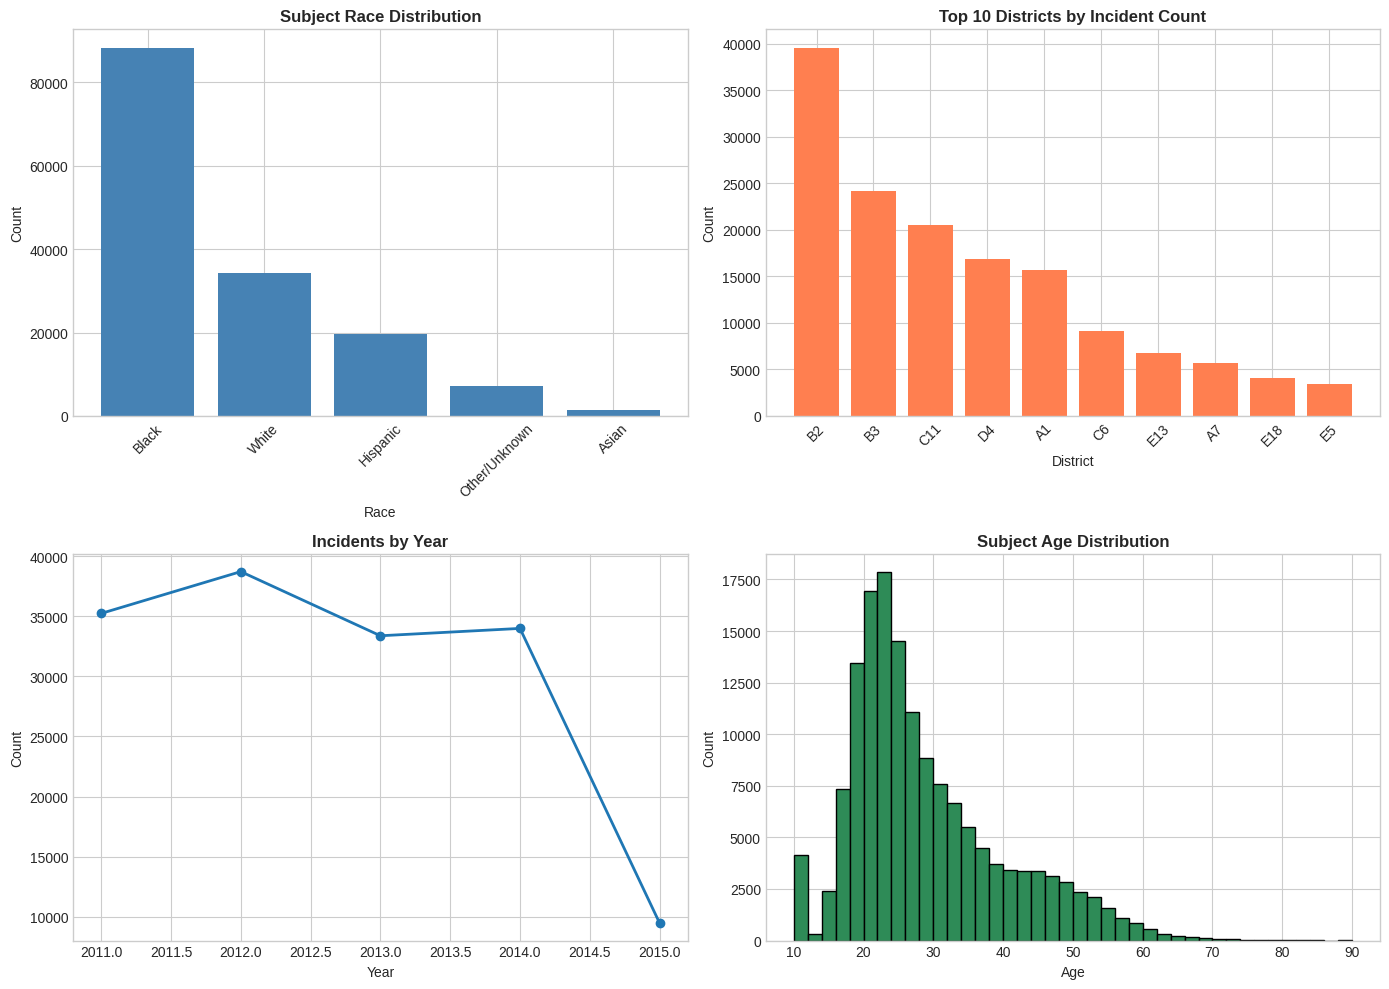

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Race distribution
race_counts = df_clean['RACE_CLEAN'].value_counts()
axes[0, 0].bar(race_counts.index, race_counts.values, color='steelblue')
axes[0, 0].set_title('Subject Race Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Race')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: District distribution
dist_counts = df_clean['DIST_CLEAN'].value_counts().head(10)
axes[0, 1].bar(dist_counts.index, dist_counts.values, color='coral')
axes[0, 1].set_title('Top 10 Districts by Incident Count', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('District')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Incidents by year
year_counts = df_clean['YEAR'].value_counts().sort_index()
axes[1, 0].plot(year_counts.index, year_counts.values, marker='o', linewidth=2)
axes[1, 0].set_title('Incidents by Year', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Count')

# Plot 4: Age distribution
axes[1, 1].hist(df_clean['AGE'], bins=40, color='seagreen', edgecolor='black')
axes[1, 1].set_title('Subject Age Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig("eda_visualizations.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Feature Engineering

In [7]:
# Select features for clustering
features = ["RACE_CLEAN", "DIST_CLEAN", "STOP_CLEAN", "PRIORS_CLEAN", "YEAR", "MONTH", "AGE"]
df_features = df_clean[features].copy()

# One-hot encode categorical features
cat_cols = ["RACE_CLEAN", "DIST_CLEAN", "STOP_CLEAN", "PRIORS_CLEAN"]
df_encoded = pd.get_dummies(df_features, columns=cat_cols, drop_first=False)

# Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

print("Feature matrix shape:", X_scaled.shape)
print("First 15 features:", df_encoded.columns[:15].tolist())

Feature matrix shape: (150775, 28)
First 15 features: ['YEAR', 'MONTH', 'AGE', 'RACE_CLEAN_Asian', 'RACE_CLEAN_Black', 'RACE_CLEAN_Hispanic', 'RACE_CLEAN_Other/Unknown', 'RACE_CLEAN_White', 'DIST_CLEAN_A1', 'DIST_CLEAN_A15', 'DIST_CLEAN_A7', 'DIST_CLEAN_B2', 'DIST_CLEAN_B3', 'DIST_CLEAN_C11', 'DIST_CLEAN_C6']


## 6. Dimensionality Reduction (PCA)

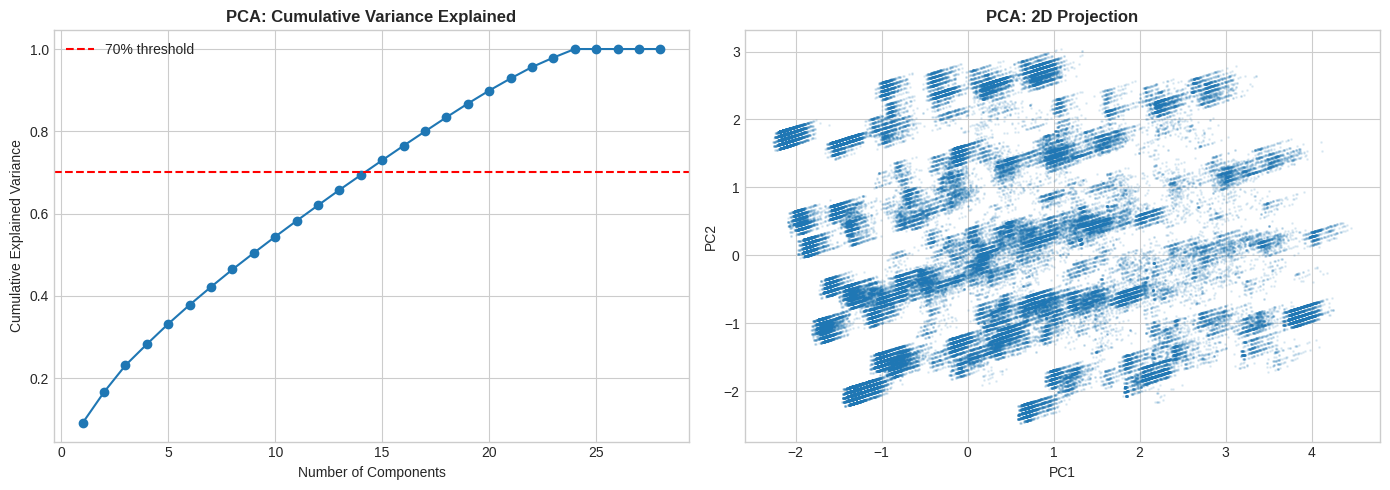

Variance explained by 15 components: 72.96%


In [8]:
# Full PCA for variance analysis
pca_full = PCA()
pca_full.fit(X_scaled)

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative variance
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
axes[0].plot(range(1, len(cum_var) + 1), cum_var, marker='o')
axes[0].axhline(y=0.7, color='r', linestyle='--', label='70% threshold')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA: Cumulative Variance Explained', fontweight='bold')
axes[0].legend()

# 2D visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.1, s=1)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA: 2D Projection', fontweight='bold')

plt.tight_layout()
plt.savefig("pca_results.png", dpi=150, bbox_inches="tight")
plt.show()

# PCA for clustering (15 components)
pca = PCA(n_components=15)
X_pca = pca.fit_transform(X_scaled)
print(f'Variance explained by 15 components: {sum(pca.explained_variance_ratio_):.2%}')

## 7. Clustering (K-Means)

Finding optimal k...
k=2: Silhouette=0.161
k=3: Silhouette=0.135
k=4: Silhouette=0.124
k=5: Silhouette=0.137
k=6: Silhouette=0.132
k=7: Silhouette=0.175
k=8: Silhouette=0.214
k=9: Silhouette=0.204
k=10: Silhouette=0.230


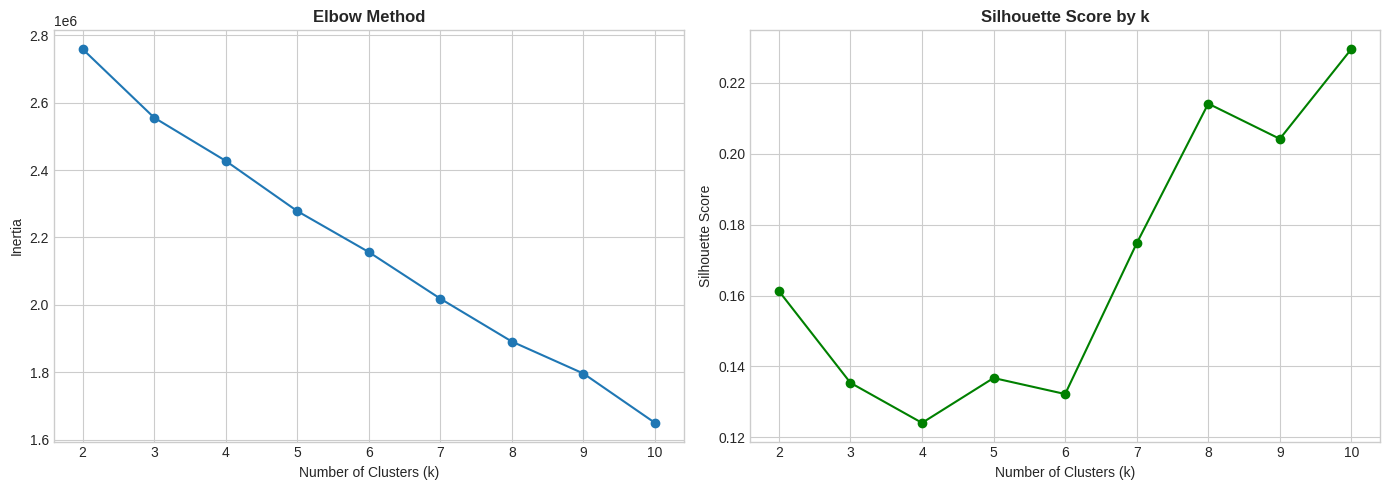


Best silhouette at k=10: 0.230


In [9]:
# Find optimal k
k_range = range(2, 11)
inertias = []
silhouettes = []

print('Finding optimal k...')
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_pca, kmeans.labels_, sample_size=20000, random_state=42)
    silhouettes.append(sil)
    print(f'k={k}: Silhouette={sil:.3f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')

axes[1].plot(k_range, silhouettes, marker='o', color='green')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k', fontweight='bold')

plt.tight_layout()
plt.savefig("clustering_optimization.png", dpi=150, bbox_inches="tight")
plt.show()

print(f'\nBest silhouette at k={list(k_range)[np.argmax(silhouettes)]}: {max(silhouettes):.3f}')

In [10]:
# Apply K-Means with k=8
best_k = 8
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clean["Cluster"] = kmeans_final.fit_predict(X_pca)

print("=" * 50)
print("CLUSTER SIZES")
print("=" * 50)
for cluster in range(best_k):
    count = (df_clean["Cluster"] == cluster).sum()
    pct = count / len(df_clean) * 100
    print(f"Cluster {cluster}: {count:,} incidents ({pct:.1f}%)")

CLUSTER SIZES
Cluster 0: 4,090 incidents (2.7%)
Cluster 1: 21,461 incidents (14.2%)
Cluster 2: 21,262 incidents (14.1%)
Cluster 3: 25,294 incidents (16.8%)
Cluster 4: 39,162 incidents (26.0%)
Cluster 5: 6,730 incidents (4.5%)
Cluster 6: 16,821 incidents (11.2%)
Cluster 7: 15,955 incidents (10.6%)


## 8. Results and Cluster Interpretation

In [11]:
# Cluster profiles
print("=" * 60)
print("CLUSTER PROFILES")
print("=" * 60)

for cluster in range(best_k):
    print(f"\n--- Cluster {cluster} ---")
    cluster_data = df_clean[df_clean["Cluster"] == cluster]
    print(f"Size: {len(cluster_data):,} ({len(cluster_data)/len(df_clean)*100:.1f}%)")

    print("\nTop stop reasons:")
    top_reasons = (cluster_data["STOP_CLEAN"].value_counts(normalize=True).head(3) * 100).round(1)
    for reason, pct in top_reasons.items():
        print(f"  {reason}: {pct}%")

    print("\nTop districts:")
    top_dists = cluster_data["DIST_CLEAN"].value_counts().head(3)
    for dist, count in top_dists.items():
        print(f"  {dist}: {count:,}")

    print("\nRace distribution (top 4):")
    race_dist = (cluster_data["RACE_CLEAN"].value_counts(normalize=True).head(4) * 100).round(1)
    for race, pct in race_dist.items():
        print(f"  {race}: {pct}%")

    print(f"\nAverage age: {cluster_data['AGE'].mean():.1f}")
    print(f"% Male: {(cluster_data['GENDER_CLEAN'] == 'MALE').mean()*100:.1f}%")

CLUSTER PROFILES

--- Cluster 0 ---
Size: 4,090 (2.7%)

Top stop reasons:
  Investigative: 47.1%
  Radio Call: 21.1%
  Vehicle: 15.0%

Top districts:
  E18: 4,090

Race distribution (top 4):
  Black: 57.6%
  White: 18.1%
  Hispanic: 17.3%
  Other/Unknown: 4.6%

Average age: 26.2
% Male: 87.3%

--- Cluster 1 ---
Size: 21,461 (14.2%)

Top stop reasons:
  Investigative: 45.2%
  Other: 15.9%
  Unknown: 15.3%

Top districts:
  C11: 20,347
  OTHER: 606
  C6: 102

Race distribution (top 4):
  Black: 65.5%
  White: 16.0%
  Hispanic: 8.0%
  Other/Unknown: 5.6%

Average age: 27.0
% Male: 84.9%

--- Cluster 2 ---
Size: 21,262 (14.1%)

Top stop reasons:
  Unknown: 42.5%
  Radio Call: 21.9%
  Investigative: 17.0%

Top districts:
  C6: 8,270
  A7: 5,129
  E5: 2,790

Race distribution (top 4):
  White: 57.3%
  Hispanic: 23.9%
  Black: 14.3%
  Other/Unknown: 4.5%

Average age: 30.1
% Male: 81.5%

--- Cluster 3 ---
Size: 25,294 (16.8%)

Top stop reasons:
  Unknown: 72.3%
  Investigative: 12.0%
  Other:

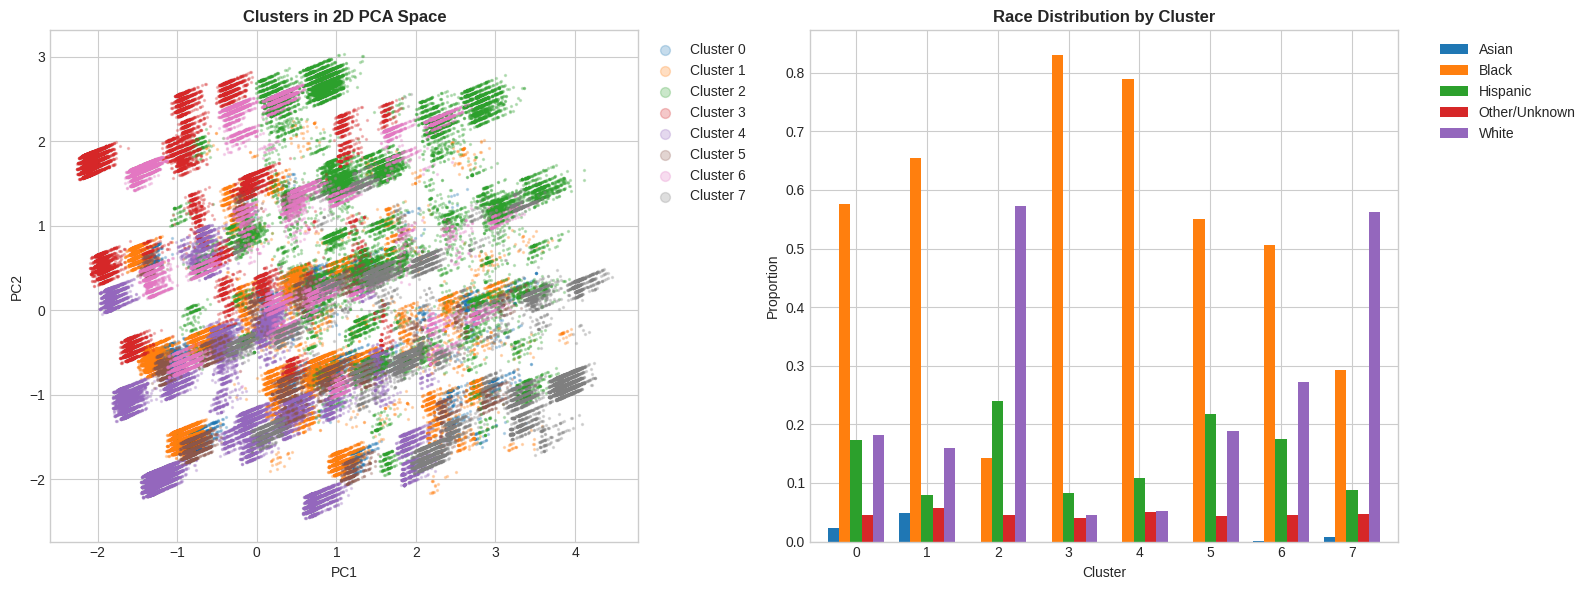

In [12]:
# Visualize clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cluster in range(best_k):
    mask = df_clean["Cluster"] == cluster
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], alpha=0.25, s=2, label=f"Cluster {cluster}")

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Clusters in 2D PCA Space", fontweight="bold")
axes[0].legend(markerscale=5, bbox_to_anchor=(1, 1), loc="upper left")

cluster_race = pd.crosstab(df_clean["Cluster"], df_clean["RACE_CLEAN"], normalize="index")
cluster_race.plot(kind="bar", ax=axes[1], width=0.8)
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Proportion")
axes[1].set_title("Race Distribution by Cluster", fontweight="bold")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("cluster_visualizations.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Summary

In [13]:
final_sil = silhouette_score(X_pca, df_clean["Cluster"], sample_size=20000, random_state=42)

print("=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)
print(f"""
Dataset: {len(df_clean):,} field interviews (2011–2015)
Features used: {X_scaled.shape[1]} after encoding
PCA components: 15 (explaining {sum(pca.explained_variance_ratio_)*100:.1f}% variance)
Clusters selected: {best_k}
Silhouette score (sample): {final_sil:.3f}

Key Findings:
1. Policing incidents are concentrated in a few districts (e.g., B2, B3, C11).
2. Clusters are strongly influenced by police district, suggesting geography is a major organizing factor.
3. The dataset is dominated by routine field interviews.
4. Clusters show meaningful differences in stop context (stop reason), location, and demographics.

Limitations:
- Missing values in several fields
- No population baseline for fairness comparisons
- Clustering reveals patterns, not proof of bias
""")

ANALYSIS SUMMARY

Dataset: 150,775 field interviews (2011–2015)
Features used: 28 after encoding
PCA components: 15 (explaining 73.0% variance)
Clusters selected: 8
Silhouette score (sample): 0.214

Key Findings:
1. Policing incidents are concentrated in a few districts (e.g., B2, B3, C11).
2. Clusters are strongly influenced by police district, suggesting geography is a major organizing factor.
3. The dataset is dominated by routine field interviews.
4. Clusters show meaningful differences in stop context (stop reason), location, and demographics.

Limitations:
- Missing values in several fields
- No population baseline for fairness comparisons
- Clustering reveals patterns, not proof of bias



---

## References

- Dataset: Center for Policing Equity – Data Science for Good
- Course: DLBDSMLUSL01 - Machine Learning: Unsupervised Learning and Feature Engineering

---

*End of Notebook*